In [223]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
import seaborn as sns
from lightgbm import LGBMClassifier
from scipy.stats import chi2_contingency, pointbiserialr
from sklearn.linear_model import LinearRegression, LogisticRegression # logistic regression model works well for binary classification problems
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, make_scorer
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier, XGBRegressor

from mlhelper import MLHelper

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

labels_dict = {
    0: {
        'name': 'Deceased',
        'color': 'r',
        'marker': '^'
    },
    1: {
        'name': 'Survived',
        'color': 'b',
        'marker': 'o'
    }
}

helper = MLHelper('Titanic', labels_dict)
df_train = pd.read_csv('../data/train.csv')
df_test = pd.read_csv('../data/test.csv')

## Data Analysis

In [224]:
# pattern = re.compile('[a-zA-Z]+')

# for i in range(len(df_train['Ticket'])):
#     ticket = df_train['Ticket'].iloc[i]
#     pclass = df_train['Pclass'].iloc[i]
#     cabin = df_train['Cabin'].iloc[i]
#     l = pattern.findall(ticket)
#     if l and pclass == 2:
#         print(pclass, ticket, cabin)


In [225]:
# for i in range(len(df_train['Ticket'])):
#     pclass = df_train['Pclass'].iloc[i]
#     cabin = df_train['Cabin'].iloc[i]
#     survived = df_train['Survived'].iloc[i]
#     if pclass == 1 and cabin is not np.nan:
#         print(pclass, cabin, survived)

In [226]:
# df_train[(df_train['Pclass'] == 3) & (df_train.duplicated(subset=['Embarked'], keep=False))]
# df_train[df_train['Ticket'].str.endswith()].sort_values(by='Pclass')
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [227]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [228]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [229]:
# need to handle missing data
df_train.isna().sum() / len(df_train['Survived'])

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

In [230]:
# need to handle missing data
df_test.isna().sum() / len(df_test['PassengerId'])

PassengerId    0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.205742
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.002392
Cabin          0.782297
Embarked       0.000000
dtype: float64

In [231]:
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [232]:
print(df_train["Name"].str.extract(r',[^.]*\b(\w+)\.').iloc[:,0].unique())
print(df_test["Name"].str.extract(r',[^.]*\b(\w+)\.').iloc[:,0].unique())

['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'Countess' 'Jonkheer']
['Mr' 'Mrs' 'Miss' 'Master' 'Ms' 'Col' 'Rev' 'Dr' 'Dona']


In [233]:
df_test[df_test['Fare'].isna()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
152,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


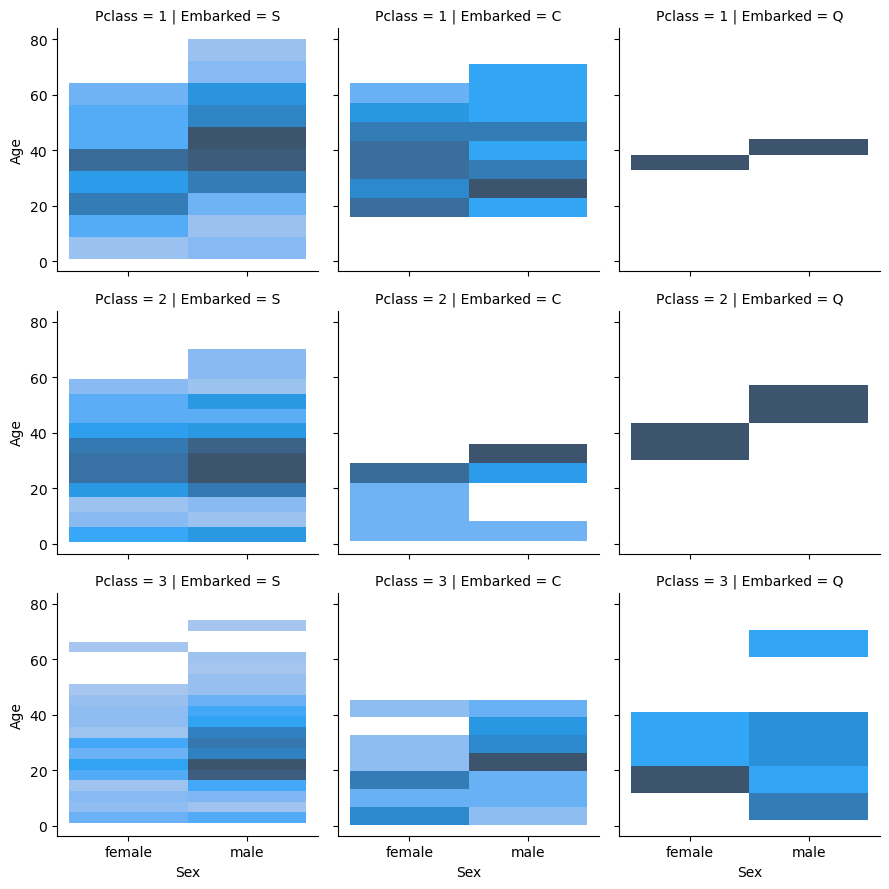

In [234]:
g = sns.FacetGrid(
    data=df_train
    , row='Pclass'
    , col='Embarked'
)

g.map(
    sns.histplot
    , 'Sex'
    , 'Age'
)

# majority of men that embarked on S/Southamton bought cheap tickets
plt.show()

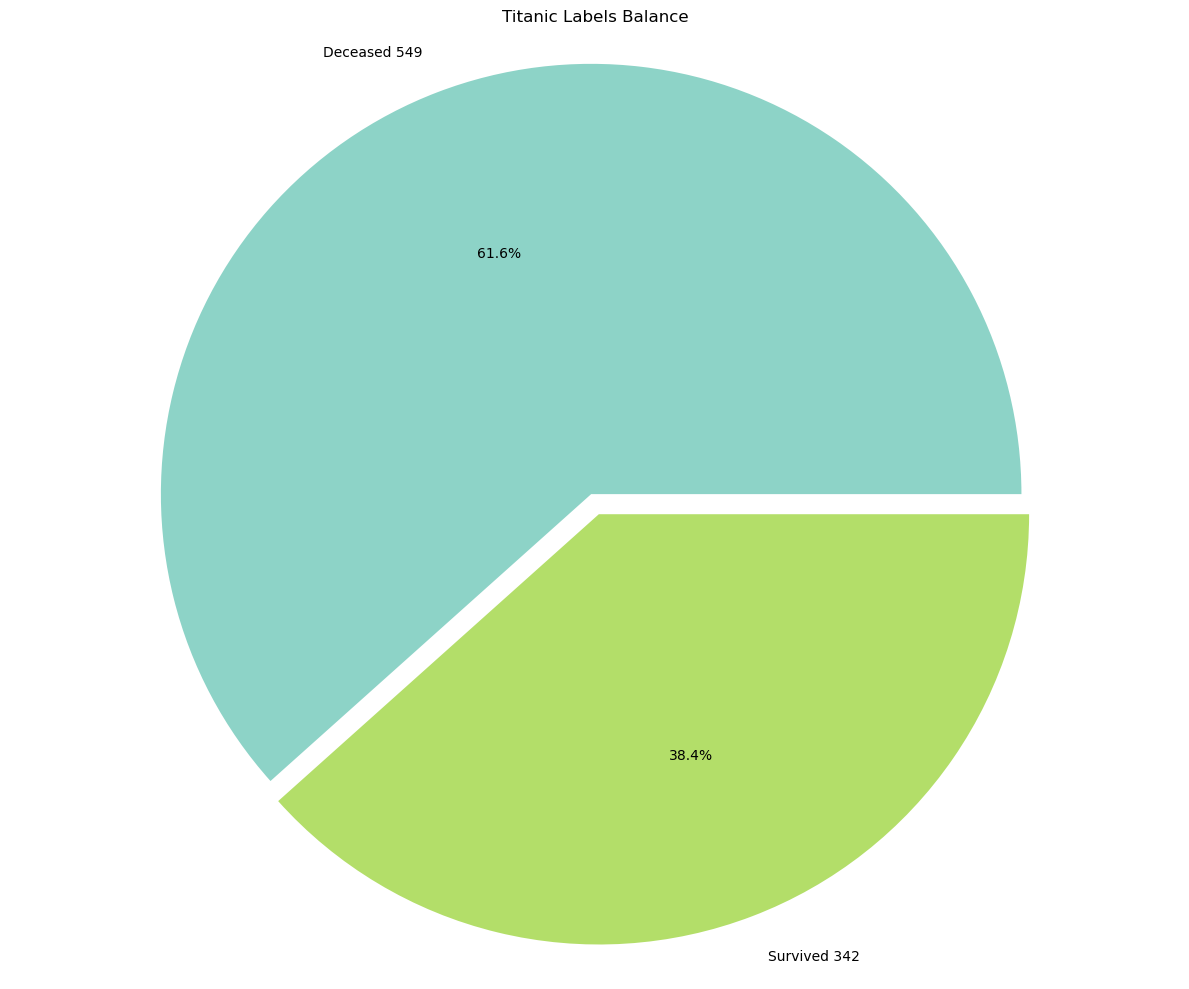

In [235]:
helper.get_label_balance(df_train['Survived'])

In [236]:
df_num = df_train[['Age','SibSp','Parch','Fare']]
df_cat = df_train[['Survived','Pclass','Sex','Ticket','Cabin','Embarked']]

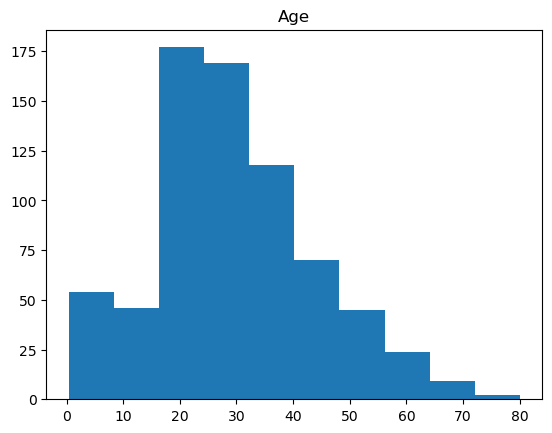

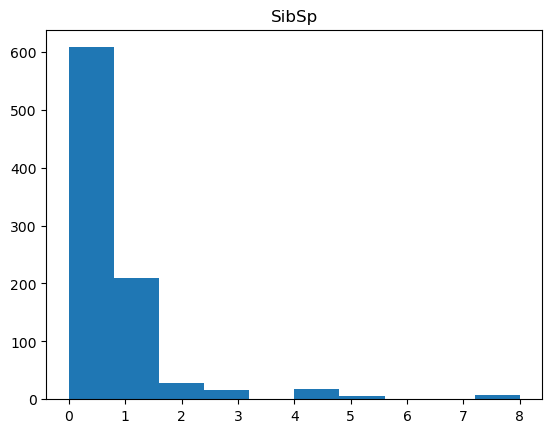

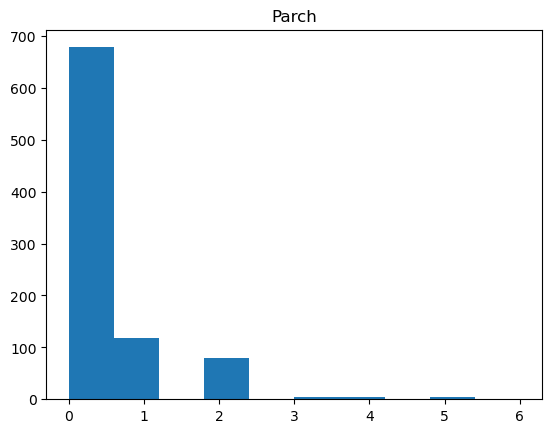

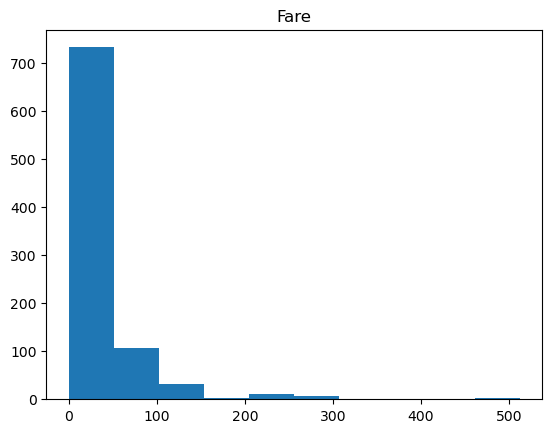

In [237]:
for i in df_num.columns:
    plt.hist(df_num[i])
    plt.title(i)
    plt.show()

            Age     SibSp     Parch      Fare
Age    1.000000 -0.308247 -0.189119  0.096067
SibSp -0.308247  1.000000  0.414838  0.159651
Parch -0.189119  0.414838  1.000000  0.216225
Fare   0.096067  0.159651  0.216225  1.000000


<Axes: >

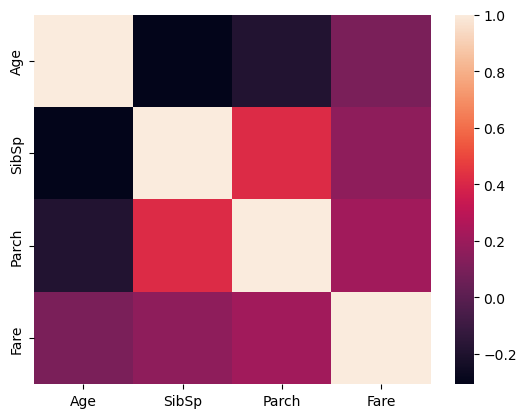

In [238]:
print(df_num.corr())
sns.heatmap(df_num.corr())

In [239]:
# compare survival rate across Age, SibSp, Parch, and Fare 
pd.pivot_table(df_train, index = 'Survived', values = ['Age','SibSp','Parch','Fare'])

,Age,Fare,Parch,SibSp
Survived,,,,
0,30.626179,22.117887,0.329690,0.553734
1,28.343690,48.395408,0.464912,0.473684


## Feature Engineering

In [240]:
# add a title feature

df_train['Title'] = df_train['Name'].str.extract(r',[^.]*\b(\w+)\.')
df_test['Title'] = df_test['Name'].str.extract(r',[^.]*\b(\w+)\.')

df_train['Title'] = df_train['Title'].replace('Mlle', 'Miss')
df_train['Title'] = df_train['Title'].replace('Ms', 'Miss')
df_train['Title'] = df_train['Title'].replace('Mme', 'Mrs')
df_test['Title'] = df_test['Title'].replace('Mlle', 'Miss')
df_test['Title'] = df_test['Title'].replace('Ms', 'Miss')
df_test['Title'] = df_test['Title'].replace('Mme', 'Mrs')

wealth_titles = ['Sir', 'Lady', 'Countess', 'Don', 'Dona', 'Jonkheer']
military_titles = ['Capt', 'Col', 'Major']
professional_titles = ['Dr', 'Rev']

def get_title_status(title):
    if title in wealth_titles:
        return 'Wealthy'
    elif title in military_titles:
        return 'Military'
    elif title in professional_titles:
        return 'Professional'
    elif title in ['Mr', 'Mrs', 'Miss', 'Master']:
        return 'Common'
    else:
        return 'Other'

df_train['TitleStatus'] = df_train['Title'].apply(get_title_status)
df_test['TitleStatus'] = df_test['Title'].apply(get_title_status)

# rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
# df_train['Title'] = df_train['Title'].replace(rare_titles, 'Rare')
# df_test['Title'] = df_test['Title'].replace(rare_titles, 'Rare')

In [241]:
# add family size feature
# in case there is a correlation between survival and family size

df_train_family_size = df_train.copy()
df_train_family_size['FamilySize'] = df_train_family_size['Parch'] + df_train_family_size['SibSp']

df_test_family_size = df_test.copy()
df_test_family_size['FamilySize'] = df_test_family_size['Parch'] + df_test_family_size['SibSp']

# add is alone feature
# in case there is a correlation between survival and if they are alone

df_train_family_size['IsAlone'] = df_train_family_size['FamilySize'] == 0
df_test_family_size['IsAlone'] = df_test_family_size['FamilySize'] == 0

In [242]:
# convert Cabin feature into CabinDeck
# makes it a categorical feature

df_train_family_size['CabinDeck'] = df_train_family_size['Cabin'].str[0]
df_train_family_size['HasCabin'] = df_train_family_size['Cabin'].notna()

df_test_family_size['CabinDeck'] = df_test_family_size['Cabin'].str[0]
df_test_family_size['HasCabin'] = df_test_family_size['Cabin'].notna()

In [243]:
df_train_family_size['CabinCount'] = df_train_family_size.Cabin.apply(lambda x: 0 if pd.isna(x) else len(x.split(' ')))
df_test_family_size['CabinCount'] = df_test_family_size.Cabin.apply(lambda x: 0 if pd.isna(x) else len(x.split(' ')))

In [244]:
# add TicketGroupSize feature
# shows how many samples have the same ticket

df_train_family_size = df_train_family_size.copy()
df_train_family_size['TicketGroupSize'] = df_train_family_size.groupby('Ticket')['Ticket'].transform('count')

df_test_family_size = df_test_family_size.copy()
df_test_family_size['TicketGroupSize'] = df_test_family_size.groupby('Ticket')['Ticket'].transform('count')

In [245]:
df_train_family_size['IsNumericTicket'] = df_train_family_size['Ticket'].apply(lambda x: 1 if x.isnumeric() else 0)
df_test_family_size['IsNumericTicket'] = df_test_family_size['Ticket'].apply(lambda x: 1 if x.isnumeric() else 0)

In [246]:
df_train_family_size.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PassengerId      891 non-null    int64  
 1   Survived         891 non-null    int64  
 2   Pclass           891 non-null    int64  
 3   Name             891 non-null    object 
 4   Sex              891 non-null    object 
 5   Age              714 non-null    float64
 6   SibSp            891 non-null    int64  
 7   Parch            891 non-null    int64  
 8   Ticket           891 non-null    object 
 9   Fare             891 non-null    float64
 10  Cabin            204 non-null    object 
 11  Embarked         889 non-null    object 
 12  Title            891 non-null    object 
 13  TitleStatus      891 non-null    object 
 14  FamilySize       891 non-null    int64  
 15  IsAlone          891 non-null    bool   
 16  CabinDeck        204 non-null    object 
 17  HasCabin        

In [247]:
df_test_family_size.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PassengerId      418 non-null    int64  
 1   Pclass           418 non-null    int64  
 2   Name             418 non-null    object 
 3   Sex              418 non-null    object 
 4   Age              332 non-null    float64
 5   SibSp            418 non-null    int64  
 6   Parch            418 non-null    int64  
 7   Ticket           418 non-null    object 
 8   Fare             417 non-null    float64
 9   Cabin            91 non-null     object 
 10  Embarked         418 non-null    object 
 11  Title            418 non-null    object 
 12  TitleStatus      418 non-null    object 
 13  FamilySize       418 non-null    int64  
 14  IsAlone          418 non-null    bool   
 15  CabinDeck        91 non-null     object 
 16  HasCabin         418 non-null    bool   
 17  CabinCount      

In [248]:
# fill Embarked nan values now to avoid headache of doing it after mapping
# going to replace missing data with most common value

# TODO use a model to predict it

most_embarked = df_train['Embarked'].mode().loc[0]
df_train_family_size['Embarked'] = df_train_family_size['Embarked'].fillna(most_embarked)

In [249]:
# fill Fare nan value in test data now to avoid headache of doing it later
# going to replace it with average value

# TODO use a model to predict it
average_fare = df_train['Fare'].mean()
df_test_family_size['Fare'] = df_test_family_size['Fare'].fillna(average_fare)

In [250]:
# add FarePerPerson feature
# shows how much a person paid for a group ticket

df_train_family_size['FarePerPerson'] = df_train_family_size['Fare'] / df_train_family_size['TicketGroupSize']
df_test_family_size['FarePerPerson'] = df_test_family_size['Fare'] / df_test_family_size['TicketGroupSize']

In [251]:
df_train_family_size['IsMale'] = df_train_family_size['Sex'] == 'male'
df_test_family_size['IsMale'] = df_test_family_size['Sex'] == 'male'

In [252]:
df_train_family_size['Pclass_Sex'] = df_train_family_size['Pclass'].astype(str) + '_' + df_train_family_size['Sex']
df_test_family_size['Pclass_Sex'] = df_test_family_size['Pclass'].astype(str) + '_' + df_test_family_size['Sex']

In [253]:
df_train_family_size['IsAlone_Sex'] = df_train_family_size['IsAlone'].astype(str) + '_' + df_train_family_size['Sex']
df_test_family_size['IsAlone_Sex'] = df_test_family_size['IsAlone'].astype(str) + '_' + df_test_family_size['Sex']

In [254]:
# drop unnecessary features

features_to_drop = ['Sex', 'Name', 'Ticket', 'SibSp', 'Parch', 'Cabin', 'Fare', 'TicketGroupSize']
df_train_family_size.drop(features_to_drop, axis=1, inplace=True)
df_test_family_size.drop(features_to_drop, axis=1, inplace=True)

In [256]:
df_train_target = df_train_family_size['Survived'].copy()

# Features to one-hot encode
cat_features = ['Pclass', 'Title', 'Embarked', 'CabinDeck', 'TitleStatus', 'CabinCount', 'Pclass_Sex', 'IsAlone_Sex']

# Ensure original categorical values (not codes)
for f in cat_features:
    df_train_family_size[f] = df_train_family_size[f].astype('category')
    df_test_family_size[f]  = df_test_family_size[f].astype('category')

ohe = OneHotEncoder(handle_unknown='ignore')

X_train_ohe = ohe.fit_transform(df_train_family_size[cat_features])
X_test_ohe  = ohe.transform(df_test_family_size[cat_features])

# Convert sparse output to dense if needed
X_train_ohe = X_train_ohe.toarray() if hasattr(X_train_ohe, "toarray") else X_train_ohe
X_test_ohe  = X_test_ohe.toarray() if hasattr(X_test_ohe, "toarray") else X_test_ohe

# Get proper column names
ohe_columns = ohe.get_feature_names_out(cat_features)

# Make DataFrames
df_train_family_size = pd.concat([df_train_family_size, pd.DataFrame(X_train_ohe, columns=ohe_columns, index=df_train_family_size.index)], axis=1).drop(cat_features, axis=1, inplace=False)
df_test_family_size  = pd.concat([df_test_family_size, pd.DataFrame(X_test_ohe, columns=ohe_columns, index=df_test_family_size.index)], axis=1).drop(cat_features, axis=1, inplace=False)

In [257]:
df_train_family_size.isna().sum() / len(df_train_target)

PassengerId                 0.000000
Survived                    0.000000
Age                         0.198653
FamilySize                  0.000000
IsAlone                     0.000000
HasCabin                    0.000000
IsNumericTicket             0.000000
FarePerPerson               0.000000
IsMale                      0.000000
Pclass_1                    0.000000
Pclass_2                    0.000000
Pclass_3                    0.000000
Title_Capt                  0.000000
Title_Col                   0.000000
Title_Countess              0.000000
Title_Don                   0.000000
Title_Dr                    0.000000
Title_Jonkheer              0.000000
Title_Lady                  0.000000
Title_Major                 0.000000
Title_Master                0.000000
Title_Miss                  0.000000
Title_Mr                    0.000000
Title_Mrs                   0.000000
Title_Rev                   0.000000
Title_Sir                   0.000000
Embarked_C                  0.000000
E

In [258]:
df_test_family_size.isna().sum() / len(df_test_family_size['PassengerId'])

PassengerId                 0.000000
Age                         0.205742
FamilySize                  0.000000
IsAlone                     0.000000
HasCabin                    0.000000
IsNumericTicket             0.000000
FarePerPerson               0.000000
IsMale                      0.000000
Pclass_1                    0.000000
Pclass_2                    0.000000
Pclass_3                    0.000000
Title_Capt                  0.000000
Title_Col                   0.000000
Title_Countess              0.000000
Title_Don                   0.000000
Title_Dr                    0.000000
Title_Jonkheer              0.000000
Title_Lady                  0.000000
Title_Major                 0.000000
Title_Master                0.000000
Title_Miss                  0.000000
Title_Mr                    0.000000
Title_Mrs                   0.000000
Title_Rev                   0.000000
Title_Sir                   0.000000
Embarked_C                  0.000000
Embarked_Q                  0.000000
E

In [259]:
helper.get_data_skew_kurtosis_shapiro(df_train_family_size.drop(['IsAlone', 'HasCabin', 'IsMale'], axis=1, inplace=False))

,Skew,Kurtosis,Shapiro stat,Shapiro p
PassengerId,0.000000,-1.200003,0.954797,6.308056e-16
Survived,0.477717,-1.771786,0.616658,1.794253e-40
Age,NaN,NaN,NaN,NaN
FamilySize,2.722848,9.101619,0.615077,1.567118e-40
IsNumericTicket,-1.105383,-0.778129,0.545258,5.975635e-43
FarePerPerson,4.373183,28.411591,0.566485,3.002591e-42
Pclass_1,1.202082,-0.555000,0.531913,2.234867e-43
Pclass_2,1.450050,0.102646,0.496861,1.876340e-44
Pclass_3,-0.205339,-1.957836,0.632781,7.330214e-40
Title_Capt,29.799348,886.001124,0.013109,3.763865e-55


In [260]:
cols_to_scale = ['FarePerPerson', 'FamilySize']
scaler = StandardScaler()
df_train_family_size['FarePerPerson'] = np.log1p(df_train_family_size['FarePerPerson'])
df_test_family_size['FarePerPerson'] = np.log1p(df_test_family_size['FarePerPerson'])
df_train_family_size['FamilySize'] = np.log1p(df_train_family_size['FamilySize'])
df_test_family_size['FamilySize'] = np.log1p(df_test_family_size['FamilySize'])
df_train_family_size[cols_to_scale] = scaler.fit_transform(df_train_family_size[cols_to_scale])
df_test_family_size[cols_to_scale] = scaler.transform(df_test_family_size[cols_to_scale])

In [261]:
# predict missing Age values using different models

df_age = df_train_family_size.drop(['Survived'], axis=1, inplace=False)
df_train_age = df_age[df_age['Age'].notna()].copy()
df_train_predict_age = df_age[df_age['Age'].isna()].copy()

age_features = df_age.drop(['Age'], axis=1, inplace=False).columns

X_train_age = df_train_age[age_features]
y_train_age = df_train_age['Age']
X_train_predict_age  = df_train_predict_age[age_features]

models = {
    'LinearRegression': {'model': LinearRegression(n_jobs=-1), 
                         'mae': 0, 
                         'mse': 0
    },
    'RandomForest': {'model': RandomForestRegressor(n_estimators=1000, n_jobs=-1, random_state=42), 
                     'mae': 0, 
                     'mse': 0
    },
    'XGBoost': {'model': XGBRegressor(n_estimators=1000, n_jobs=-1, random_state=42), 
                'mae': 0, 
                'mse': 0
    }
}

for name, model_info in models.items():
    model = model_info['model']
    mae_score = cross_val_score(model, X_train_age, y_train_age, cv=5,
                                scoring=make_scorer(mean_absolute_error)).mean()
    mse_score = cross_val_score(model, X_train_age, y_train_age, cv=5,
                                scoring=make_scorer(mean_squared_error)).mean()
    model_info['mae'] = mae_score
    model_info['mse'] = mse_score
    print(f"{name}: Mean MAE = {mae_score:.3f}, Mean MSE = {mse_score:.3f}")

LinearRegression: Mean MAE = 8.735, Mean MSE = 125.458
RandomForest: Mean MAE = 9.241, Mean MSE = 139.368
XGBoost: Mean MAE = 9.979, Mean MSE = 159.872


In [262]:
# Example: give 70% weight to MSE and 30% to MAE
model_name = min(models, key=lambda x: 0.7 * models[x]['mse'] + 0.3 * models[x]['mae'])
model = models[model_name]['model']
model.fit(X_train_age, y_train_age)
df_train_predict_age['Age_pred'] = model.predict(X_train_predict_age)
print('Model used:', model_name)

Model used: LinearRegression


In [263]:
df_train_clean = df_train_family_size.copy()
df_train_clean = df_train_clean.merge(
    df_train_predict_age[['PassengerId', 'Age_pred']],
    on='PassengerId',
    how='left'
)
df_train_clean['Age'] = df_train_clean['Age'].fillna(df_train_clean['Age_pred'])
df_train_clean['Age'] = df_train_clean['Age'].clip(lower=0, upper=100)
df_train_clean.drop(columns=['Age_pred'], inplace=True)

In [264]:
df_age = df_test_family_size.copy()
df_test_age = df_age[df_age['Age'].notna()].copy()
df_test_predict_age = df_age[df_age['Age'].isna()].copy()

X_test_age = df_test_age[age_features]
y_test_age = df_test_age['Age']
X_test_predict_age  = df_test_predict_age[age_features]

df_test_predict_age['Age_pred'] = model.predict(X_test_predict_age)

df_test_clean = df_test_family_size.copy()
df_test_clean = df_test_clean.merge(
    df_test_predict_age[['PassengerId', 'Age_pred']],
    on='PassengerId',
    how='left'
)
df_test_clean['Age'] = df_test_clean['Age'].fillna(df_test_clean['Age_pred'])
df_test_clean['Age'] = df_test_clean['Age'].clip(lower=0, upper=100)
df_test_clean.drop(columns=['Age_pred'], inplace=True)

In [265]:
df_train_clean[cols_to_scale] = scaler.inverse_transform(df_train_clean[cols_to_scale])
df_test_clean[cols_to_scale] = scaler.inverse_transform(df_test_clean[cols_to_scale])

In [266]:
df_train_clean['IsChild'] = df_train_clean['Age'] < 18
df_test_clean['IsChild'] = df_test_clean['Age'] < 18

In [267]:
cols_to_scale = ['Age', 'FarePerPerson', 'FamilySize']
scaler = StandardScaler()
df_train_clean[cols_to_scale] = scaler.fit_transform(df_train_clean[cols_to_scale])
df_test_clean[cols_to_scale] = scaler.transform(df_test_clean[cols_to_scale])

In [268]:
df_train_clean.head()

,PassengerId,Survived,Age,FamilySize,IsAlone,HasCabin,IsNumericTicket,FarePerPerson,IsMale,Pclass_1,Pclass_2,Pclass_3,Title_Capt,Title_Col,Title_Countess,Title_Don,Title_Dr,Title_Jonkheer,Title_Lady,Title_Major,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rev,Title_Sir,Embarked_C,Embarked_Q,Embarked_S,CabinDeck_A,CabinDeck_B,CabinDeck_C,CabinDeck_D,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,CabinDeck_nan,TitleStatus_Common,TitleStatus_Military,TitleStatus_Professional,TitleStatus_Wealthy,CabinCount_0,CabinCount_1,CabinCount_2,CabinCount_3,CabinCount_4,Pclass_Sex_1_female,Pclass_Sex_1_male,Pclass_Sex_2_female,Pclass_Sex_2_male,Pclass_Sex_3_female,Pclass_Sex_3_male,IsAlone_Sex_False_female,IsAlone_Sex_False_male,IsAlone_Sex_True_female,IsAlone_Sex_True_male,IsChild
0,1,0,-0.569922,0.448265,False,False,0,-0.641064,True,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,False
1,2,1,0.609465,0.448265,False,True,0,2.200411,False,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,False
2,3,1,-0.275076,-0.717091,True,False,0,-0.538104,False,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,False
3,4,1,0.388330,0.448265,False,True,1,0.937563,False,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,False
4,5,0,0.388330,-0.717091,True,False,1,-0.519895,True,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,False


In [269]:
X_train = df_train_clean.drop(['PassengerId','Survived'], axis=1, inplace=False)
y_train = df_train_clean['Survived']
X_test = df_test_clean.drop(['PassengerId'], axis=1, inplace=False)

In [270]:
X_train.head()

,Age,FamilySize,IsAlone,HasCabin,IsNumericTicket,FarePerPerson,IsMale,Pclass_1,Pclass_2,Pclass_3,Title_Capt,Title_Col,Title_Countess,Title_Don,Title_Dr,Title_Jonkheer,Title_Lady,Title_Major,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rev,Title_Sir,Embarked_C,Embarked_Q,Embarked_S,CabinDeck_A,CabinDeck_B,CabinDeck_C,CabinDeck_D,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,CabinDeck_nan,TitleStatus_Common,TitleStatus_Military,TitleStatus_Professional,TitleStatus_Wealthy,CabinCount_0,CabinCount_1,CabinCount_2,CabinCount_3,CabinCount_4,Pclass_Sex_1_female,Pclass_Sex_1_male,Pclass_Sex_2_female,Pclass_Sex_2_male,Pclass_Sex_3_female,Pclass_Sex_3_male,IsAlone_Sex_False_female,IsAlone_Sex_False_male,IsAlone_Sex_True_female,IsAlone_Sex_True_male,IsChild
0,-0.569922,0.448265,False,False,0,-0.641064,True,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,False
1,0.609465,0.448265,False,True,0,2.200411,False,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,False
2,-0.275076,-0.717091,True,False,0,-0.538104,False,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,False
3,0.388330,0.448265,False,True,1,0.937563,False,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,False
4,0.388330,-0.717091,True,False,1,-0.519895,True,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,False


In [271]:
X_train.describe()

,Age,FamilySize,IsNumericTicket,FarePerPerson,Pclass_1,Pclass_2,Pclass_3,Title_Capt,Title_Col,Title_Countess,Title_Don,Title_Dr,Title_Jonkheer,Title_Lady,Title_Major,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rev,Title_Sir,Embarked_C,Embarked_Q,Embarked_S,CabinDeck_A,CabinDeck_B,CabinDeck_C,CabinDeck_D,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,CabinDeck_nan,TitleStatus_Common,TitleStatus_Military,TitleStatus_Professional,TitleStatus_Wealthy,CabinCount_0,CabinCount_1,CabinCount_2,CabinCount_3,CabinCount_4,Pclass_Sex_1_female,Pclass_Sex_1_male,Pclass_Sex_2_female,Pclass_Sex_2_male,Pclass_Sex_3_female,Pclass_Sex_3_male,IsAlone_Sex_False_female,IsAlone_Sex_False_male,IsAlone_Sex_True_female,IsAlone_Sex_True_male
count,8.910000e+02,8.910000e+02,891.000000,8.910000e+02,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,-2.312653e-16,-7.974666e-17,0.741863,-3.169930e-16,0.242424,0.206510,0.551066,0.001122,0.002245,0.001122,0.001122,0.007856,0.001122,0.001122,0.002245,0.044893,0.207632,0.580247,0.141414,0.006734,0.001122,0.188552,0.086420,0.725028,0.016835,0.052750,0.066218,0.037037,0.035915,0.014590,0.004489,0.001122,0.771044,0.974186,0.005612,0.014590,0.005612,0.771044,0.202020,0.017957,0.006734,0.002245,0.105499,0.136925,0.085297,0.121212,0.161616,0.389450,0.210999,0.186308,0.141414,0.461279
std,1.000562e+00,1.000562e+00,0.437855,1.000562e+00,0.428790,0.405028,0.497665,0.033501,0.047351,0.033501,0.033501,0.088337,0.033501,0.033501,0.047351,0.207186,0.405840,0.493796,0.348644,0.081830,0.033501,0.391372,0.281141,0.446751,0.128725,0.223659,0.248802,0.188959,0.186182,0.119973,0.066890,0.033501,0.420397,0.158668,0.074743,0.119973,0.074743,0.420397,0.401733,0.132871,0.081830,0.047351,0.307368,0.343961,0.279481,0.326557,0.368305,0.487899,0.408247,0.389573,0.348644,0.498778
min,-2.183429e+00,-7.170905e-01,0.000000,-3.403767e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-5.699223e-01,-7.170905e-01,0.000000,-5.621616e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-5.394047e-02,-7.170905e-01,1.000000,-4.089961e-01,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.357531e-01,4.482648e-01,1.000000,8.237094e-01,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.0

In [272]:
helper.get_data_skew_kurtosis_shapiro(X_train.drop(['IsAlone', 'HasCabin', 'IsMale', 'IsChild'], axis=1, inplace=False))

,Skew,Kurtosis,Shapiro stat,Shapiro p
Age,0.338391,0.496784,0.981179,2.629739e-09
FamilySize,1.182014,0.445786,0.731512,1.490335e-35
IsNumericTicket,-1.105383,-0.778129,0.545258,5.975635e-43
FarePerPerson,0.329665,1.930584,0.876303,5.371343e-26
Pclass_1,1.202082,-0.555000,0.531913,2.234867e-43
Pclass_2,1.450050,0.102646,0.496861,1.876340e-44
Pclass_3,-0.205339,-1.957836,0.632781,7.330214e-40
Title_Capt,29.799348,886.001124,0.013109,3.763865e-55
Title_Col,21.035737,440.502250,0.022758,5.498191e-55
Title_Countess,29.799348,886.001124,0.013109,3.763865e-55


In [ ]:
models = ['knnc', 'lgbmc', 'logr', 'rfc', 'svc', 'xgbc']
predictions = {}
for model in models:
    _, score, params = helper._get_optimized_params_classification(model, X_train, y_train, False, 'accuracy', 50)
    clf = helper._get_model(model, params)
    clf.fit(X_train, y_train)
    predictions[model] = {
                            'model': clf,
                            'score': score,
                            'prediction': clf.predict(X_test)
                          }

[I 2025-11-06 15:09:01,270] A new study created in memory with name: no-name-8553090f-2b33-4400-a55f-5cb9382790d9
[I 2025-11-06 15:09:01,306] Trial 0 finished with value: 0.811461929571276 and parameters: {'n_neighbors': 12, 'weights': 'uniform', 'algorithm': 'auto', 'leaf_size': 45, 'p': 2}. Best is trial 0 with value: 0.811461929571276.
[I 2025-11-06 15:09:01,336] Trial 1 finished with value: 0.8047078023978406 and parameters: {'n_neighbors': 22, 'weights': 'distance', 'algorithm': 'auto', 'leaf_size': 22, 'p': 2}. Best is trial 0 with value: 0.811461929571276.
[I 2025-11-06 15:09:01,366] Trial 2 finished with value: 0.8024606113866047 and parameters: {'n_neighbors': 13, 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 42, 'p': 1}. Best is trial 0 with value: 0.811461929571276.
[I 2025-11-06 15:09:01,396] Trial 3 finished with value: 0.8137028435126483 and parameters: {'n_neighbors': 16, 'weights': 'uniform', 'algorithm': 'brute', 'leaf_size': 49, 'p': 2}. Best is trial 3 wi

Model: knnc
  Best trial:
  accuracy: 0.815956311593748
  Best hyperparameters:  {'n_neighbors': 8, 'weights': 'uniform', 'algorithm': 'brute', 'leaf_size': 10, 'p': 2}


[I 2025-11-06 15:09:05,853] A new study created in memory with name: no-name-52aef522-6e01-4db0-a0db-a312462568a0
[W 2025-11-06 15:09:05,879] Trial 0 failed with parameters: {'n_estimators': 3808, 'learning_rate': 0.22648248189516848, 'num_leaves': 76, 'max_depth': 8, 'min_child_samples': 19, 'subsample': 0.49359671220172163, 'colsample_bytree': 0.4348501673009197, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598} because of the following error: ValueError('\nAll the 5 fits failed.\nIt is very likely that your model is misconfigured.\nYou can try to debug the error by setting error_score=\'raise\'.\n\nBelow are more details about the failures:\n--------------------------------------------------------------------------------\n5 fits failed with the following error:\nTraceback (most recent call last):\n  File "c:\\ProgramData\\anaconda3\\envs\\ml_dev\\lib\\site-packages\\sklearn\\model_selection\\_validation.py", line 895, in _fit_and_score\n    estimator.fit(X_train, 

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\ProgramData\anaconda3\envs\ml_dev\lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\ProgramData\anaconda3\envs\ml_dev\lib\site-packages\lightgbm\sklearn.py", line 1560, in fit
    super().fit(
  File "c:\ProgramData\anaconda3\envs\ml_dev\lib\site-packages\lightgbm\sklearn.py", line 1049, in fit
    self._Booster = train(
  File "c:\ProgramData\anaconda3\envs\ml_dev\lib\site-packages\lightgbm\engine.py", line 297, in train
    booster = Booster(params=params, train_set=train_set)
  File "c:\ProgramData\anaconda3\envs\ml_dev\lib\site-pa

In [ ]:
for model, model_info in predictions.items():
    prediciton_to_save = pd.DataFrame.from_dict({'PassengerId': df_test_clean['PassengerId'], 'Survived': model_info['prediction']})
    prediciton_to_save.to_csv(f'{model}_submission.csv', index=False)

In [ ]:
labels = pd.read_csv('../data/test_augmented.csv')['Survived']
knnc = pd.read_csv('knnc_submission.csv')['Survived']
lgbmc = pd.read_csv('lgbmc_submission.csv')['Survived']
logr = pd.read_csv('logr_submission.csv')['Survived']
rfc = pd.read_csv('rfc_submission.csv')['Survived']
svc = pd.read_csv('svc_submission.csv')['Survived']
xgbc = pd.read_csv('xgbc_submission.csv')['Survived']

print(f"KNNC test accuracy: {accuracy_score(labels, knnc)}, train accuracy: {predictions['knnc']['score']}")
print(f"LGBMC test accuracy: {accuracy_score(labels, lgbmc)}, train accuracy: {predictions['lgbmc']['score']}")
print(f"LOGR test accuracy: {accuracy_score(labels, logr)}, train accuracy: {predictions['logr']['score']}")
print(f"RFC test accuracy: {accuracy_score(labels, rfc)}, train accuracy: {predictions['rfc']['score']}")
print(f"SVC test accuracy: {accuracy_score(labels, svc)}, train accuracy: {predictions['svc']['score']}")
print(f"XGBC test accuracy: {accuracy_score(labels, xgbc)}, train accuracy: {predictions['xgbc']['score']}")

KNNC test accuracy: 0.7799043062200957, train accuracy: 0.8193145439708743
LGBMC test accuracy: 0.7583732057416268, train accuracy: 0.8417425145941874
LOGR test accuracy: 0.7751196172248804, train accuracy: 0.8305128366078713
RFC test accuracy: 0.7870813397129187, train accuracy: 0.828278199736363
SVC test accuracy: 0.777511961722488, train accuracy: 0.8282844768062269
XGBC test accuracy: 0.7559808612440191, train accuracy: 0.8439834285355596


In [ ]:
'''
KNNC test accuracy: 0.7751196172248804, train accuracy: 0.8226978846274559
LGBMC test accuracy: 0.7631578947368421, train accuracy: 0.84509446990145
LOGR test accuracy: 0.7727272727272727, train accuracy: 0.8249136902893728
RFC test accuracy: 0.7870813397129187, train accuracy: 0.8293955181721172
SVC test accuracy: 0.7727272727272727, train accuracy: 0.828278199736363
XGBC test accuracy: 0.7392344497607656, train accuracy: 0.8495951289937856
'''

'\nKNNC test accuracy: 0.7751196172248804, train accuracy: 0.8226978846274559\nLGBMC test accuracy: 0.7631578947368421, train accuracy: 0.84509446990145\nLOGR test accuracy: 0.7727272727272727, train accuracy: 0.8249136902893728\nRFC test accuracy: 0.7870813397129187, train accuracy: 0.8293955181721172\nSVC test accuracy: 0.7727272727272727, train accuracy: 0.828278199736363\nXGBC test accuracy: 0.7392344497607656, train accuracy: 0.8495951289937856\n'